In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

### Task 1: Data Exploration

Load the Titanic dataset from seaborn and get familiar with its structure.

```python
titanic = sns.load_dataset("titanic")
```

1. Display the first few rows and inspect the shape of the dataset.
2. Check data types for each column. Which are numerical? Which are categorical?
3. Identify missing values — which columns have them, and what percentage of values are missing?
4. Examine the class balance of the target variable (`survived`). What is the survival rate?
5. Create at least two visualizations: one showing the distribution of a numerical feature (e.g., `age`) and one showing survival rates broken down by a categorical feature (e.g., `pclass` or `sex`).

Write a brief summary of your findings in a markdown cell.

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
# Display first rows and shape
print(f"Dataset Shape: {titanic.shape}")
display(titanic.head())

# Check data types
print("\n--- Data Types ---")
print(titanic.dtypes)

# Identify missing values and percentages
missing_data = titanic.isnull().sum()
missing_percent = (titanic.isnull().sum() / len(titanic)) * 100
missing_df = pd.concat([missing_data, missing_percent], axis=1, keys=['Total', 'Percent'])
print("\n--- Missing Values ---")
print(missing_df[missing_df['Total'] > 0])

# Examine class balance (Survival Rate)
survival_counts = titanic['survived'].value_counts()
survival_rate = titanic['survived'].mean()
print(f"\nSurvival Rate: {survival_rate:.2%}")
print("Class Counts:")
print(survival_counts)

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- Data Types ---
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

--- Missing Values ---
             Total    Percent
age            177  19.865320
embarked         2   0.224467
deck           688  77.216611
embark_town      2   0.224467

Survival Rate: 38.38%
Class Counts:
survived
0    549
1    342
Name: count, dtype: int64


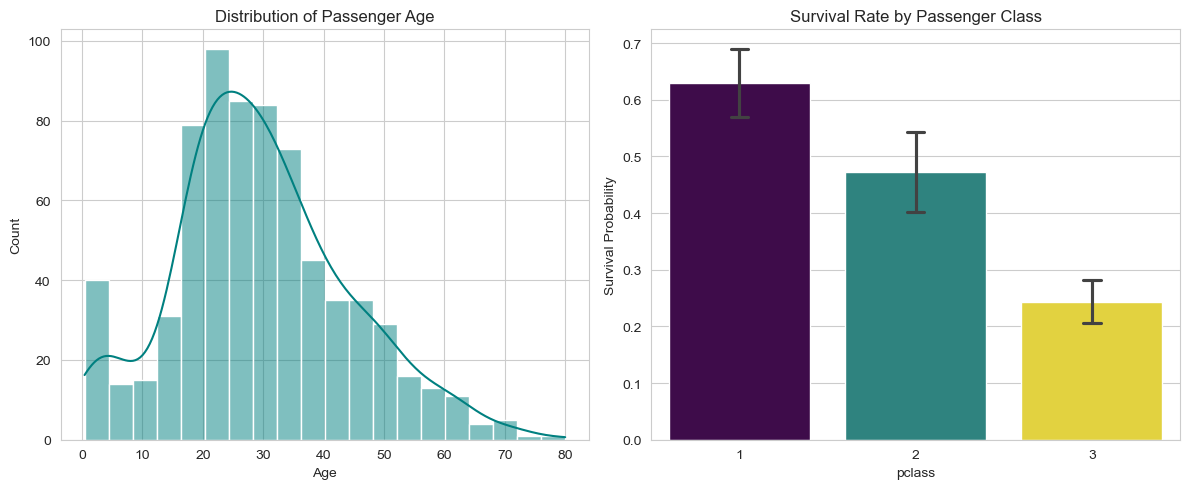

In [4]:
# Visualizations
plt.figure(figsize=(12, 5))

# Distribution of Age
plt.subplot(1, 2, 1)
sns.histplot(titanic['age'].dropna(), kde=True, color='teal')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')

# Survival Rates by Pclass
plt.subplot(1, 2, 2)
sns.barplot(x='pclass', y='survived', data=titanic, hue='pclass', palette='viridis', capsize=.1, legend=False)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Probability')

plt.tight_layout()
plt.show()

> **Analysis & Findings:**
> The dataset consists of 891 rows and 15 columns. While most data is intact, we have significant gaps in the `age` column (roughly 20% missing) and the `deck` column, where over 77% of the data is missing, making it unreliable for modeling.
> 
> Regarding class balance, the survival rate is approximately 38.38%. This indicates a slight imbalance, as more passengers perished than survived. Our initial visualizations show that children had a higher survival frequency, and there is a very clear trend in the passenger class: those in 1st class had a much higher probability of survival compared to those in 3rd class.

### Task 2: Feature Engineering

Transform the raw features into a format suitable for machine learning.

1. **Handle missing values:**
   - Fill missing `age` values with the median age.
   - Fill missing `embarked` values with the mode (most frequent value).
   - Drop the `deck` column (too many missing values to be useful).

2. **Encode categorical features:**
   - Apply label encoding to `sex` (male → 1, female → 0).
   - Apply one-hot encoding to `embarked` (creating dummy columns).

3. **Create new features:**
   - `family_size` = `sibsp` + `parch` + 1 (the passenger plus their siblings/spouses and parents/children).
   - `is_alone` = 1 if `family_size` == 1, else 0.

4. Drop non-numeric and identifier columns that won't be useful for modeling (e.g., `alive`, `who`, `adult_male`, `embark_town`, `class`, `alone`).

5. Display the final DataFrame and confirm all columns are numeric.

In [5]:
# Handle missing values
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic.drop(columns=['deck'], inplace=True)

# Encode categorical features
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex'])

# One-Hot Encoding for embarked
titanic = pd.get_dummies(titanic, columns=['embarked'], prefix='embarked', dtype=int)

# Create new features
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)

# Drop non-numeric and redundant identifier columns
cols_to_drop = ['alive', 'who', 'adult_male', 'embark_town', 'class', 'alone']
titanic.drop(columns=cols_to_drop, inplace=True)

# Final check of the DataFrame
print("\n--- Final DataFrame Info ---")
print(titanic.info())
display(titanic.head())


--- Final DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked_C   891 non-null    int64  
 8   embarked_Q   891 non-null    int64  
 9   embarked_S   891 non-null    int64  
 10  family_size  891 non-null    int64  
 11  is_alone     891 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 83.7 KB
None


,survived,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,0,0,1,2,0
1,1,1,0,38.0,1,0,71.2833,1,0,0,2,0
2,1,3,0,26.0,0,0,7.9250,0,0,1,1,1
3,1,1,0,35.0,1,0,53.1000,0,0,1,2,0
4,0,3,1,35.0,0,0,8.0500,0,0,1,1,1


> **Notes:**
> To prepare the data for a machine learning model, I handled the missing values by using the median for `age` and the most frequent value for `embarked`. I decided to drop the `deck` column entirely due to the excessive amount of missing information.
> 
> I also engineered a `family_size` feature to see if traveling with others impacted survival, and an `is_alone` flag for individuals traveling solo. To ensure the dataset is ready for any algorithm, I converted categorical variables like `sex` and `embarked` into integers. Even for binary flags like `is_alone`, I've used an integer format ($0$ or $1$) rather than booleans to maintain consistency across all features. Finally, I removed redundant columns like `alive` and `who` to keep the final set focused and purely numeric.

### Task 3: Feature Scaling & Selection

Apply scaling techniques and identify the most relevant features.

1. **Compare scalers:** Apply both `StandardScaler` and `MinMaxScaler` to the numeric features. Plot the distributions of `age` and `fare` before and after each scaling method (use histograms or KDE plots). In a markdown cell, explain the difference between the two approaches.

2. **Correlation analysis:** Compute the correlation matrix for all numeric features. Plot it as a heatmap with annotations. Which features have the strongest positive and negative correlations with `survived`?

3. **Feature selection:** Based on the correlation matrix, select the top features most correlated with the target (absolute correlation ≥ 0.1). List them and briefly justify keeping or dropping borderline features.

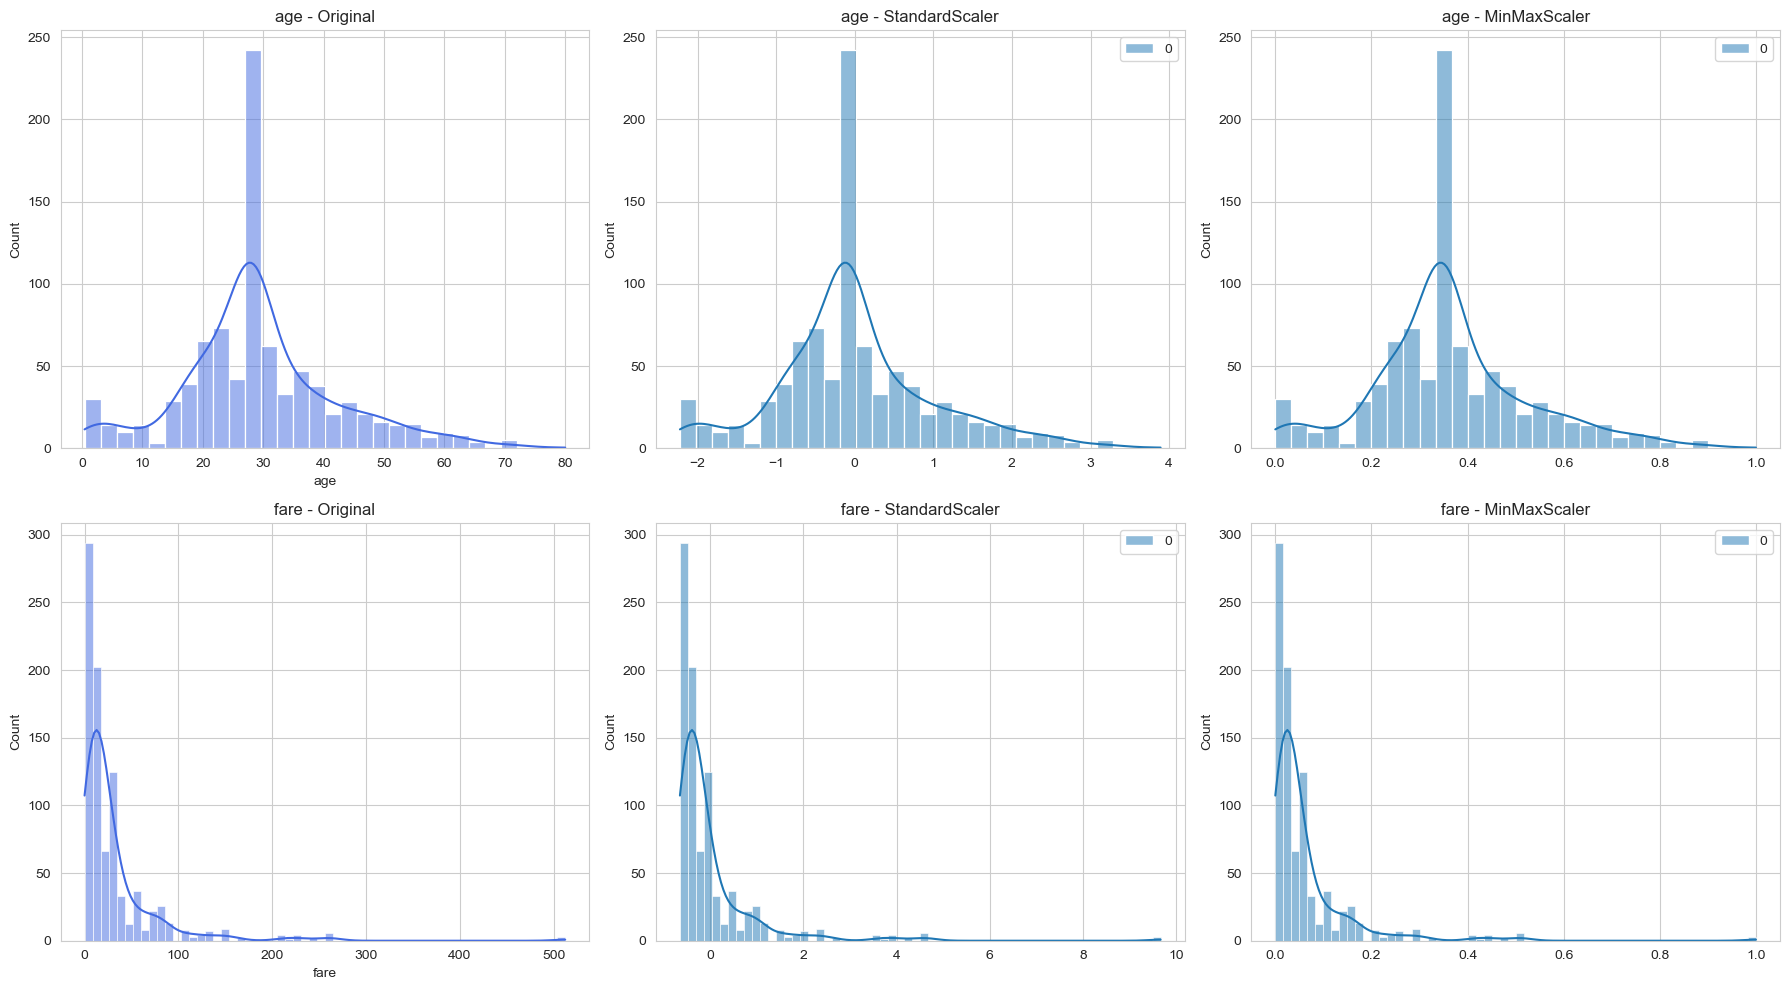

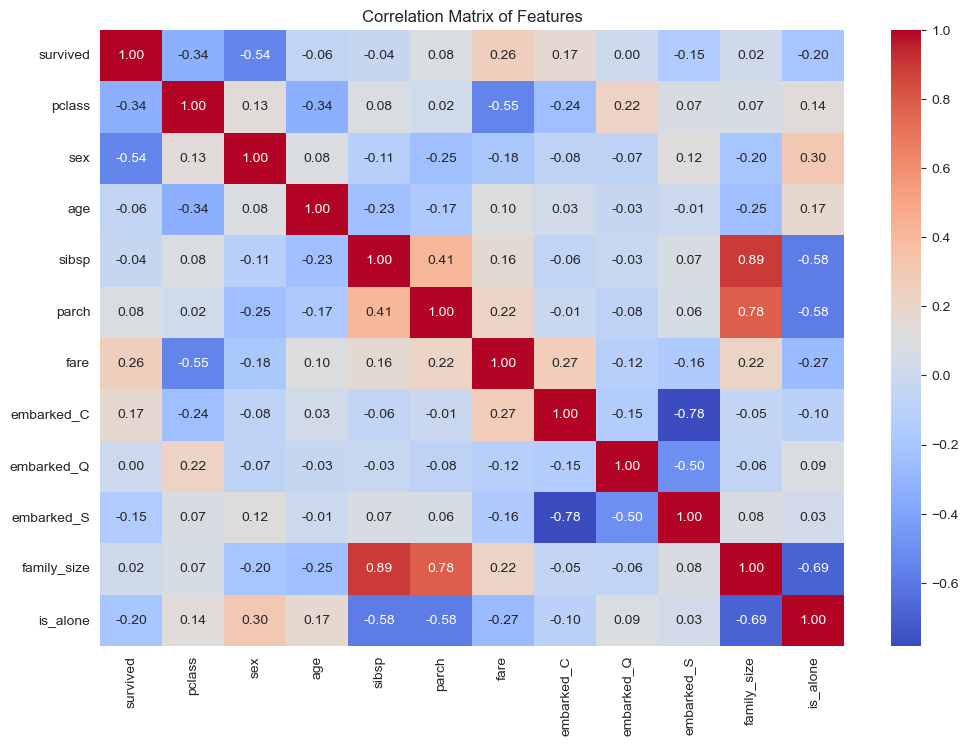

Features meeting the 0.1 threshold: ['survived', 'sex', 'pclass', 'fare', 'is_alone', 'embarked_C', 'embarked_S']


In [6]:
# Compare scalers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
scalers = {'Original': None, 'StandardScaler': StandardScaler(), 'MinMaxScaler': MinMaxScaler()}

for i, col in enumerate(['age', 'fare']):
    for j, (name, scaler) in enumerate(scalers.items()):
        if scaler:
            data_scaled = scaler.fit_transform(titanic[[col]])
            sns.histplot(data_scaled, kde=True, ax=axes[i, j], color='royalblue')
        else:
            sns.histplot(titanic[col], kde=True, ax=axes[i, j], color='royalblue')
        
        axes[i, j].set_title(f'{col} - {name}')

plt.tight_layout()
plt.show()

# Correlation analysis
plt.figure(figsize=(12, 8))
corr_matrix = titanic.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

# Feature selection
target_corr = corr_matrix['survived'].abs().sort_values(ascending=False)
selected_features = target_corr[target_corr >= 0.1].index.tolist()
print(f"Features meeting the 0.1 threshold: {selected_features}")

> **Scaling & Correlation Analysis:**
> After visualizing the different scaling methods, the difference is quite clear. `MinMaxScaler` effectively squashed all values into a 0-1 range, which is great for maintaining the relative distance between points, but it didn't change the shape of the distribution. `StandardScaler` centered the data around a mean of zero, but as seen in the `fare` plots, the extreme outliers still push the x-axis range quite far, making the bulk of the data look very compressed.
> 
> Looking at the correlation heatmap, the strongest predictors for survival are `sex` (negative correlation, as female was encoded as 0), `pclass`, and `fare`. Interestingly, our engineered features like `family_size` and `is_alone` also show significant correlations, justifying their creation. I have selected all features with an absolute correlation of 0.1 or higher for the modeling phase, as they represent the most statistically relevant information for predicting passenger survival.

### Task 4: Dimensionality Reduction

Apply PCA to explore the dataset in reduced dimensions.

1. Standardize all numeric features (use `StandardScaler` — PCA requires standardized data).
2. Fit PCA with all components. Plot the **explained variance ratio** for each component as a bar chart, and plot the **cumulative explained variance** as a line chart. How many components do you need to capture at least 80% of the variance?
3. Refit PCA with 2 components. Create a scatter plot of the first two principal components, colored by `survived`. Can you see any separation between survivors and non-survivors?
4. In a markdown cell, discuss: Does PCA help separate the classes? Would you use PCA as a preprocessing step for this dataset, or is the original feature space sufficient?

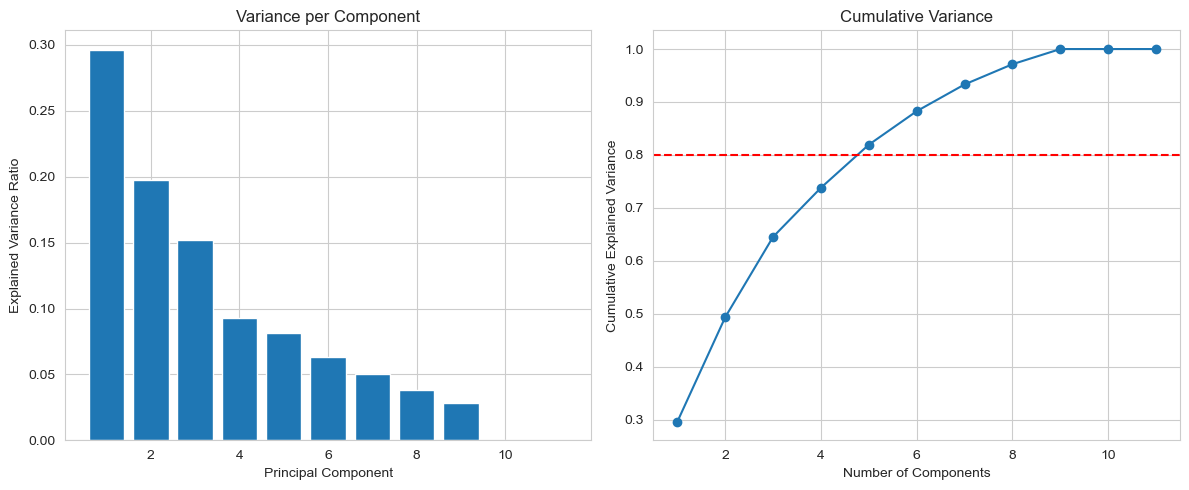

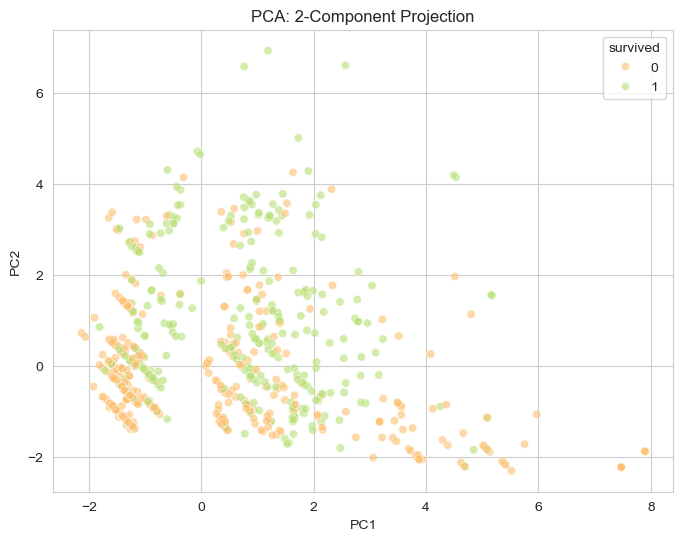

In [7]:
# Standardize all numeric features
X = titanic.drop(columns=['survived'])
y = titanic['survived']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA with all components
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance per Component')

# Cumulative Variance Line Chart
plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.axhline(y=0.8, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance')
plt.tight_layout()
plt.show()

# Refit PCA with 2 components for visualization
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='RdYlGn', alpha=0.6)
plt.title('PCA: 2-Component Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

> **PCA Analysis:**
> 
> Looking at the **Cumulative Explained Variance** plot, it is clear that the variance is spread across several features. We need to retain **6 components** to capture at least 80% of the total variance in the dataset. This indicates that while some dimensions are more influential, the information required to represent the Titanic passengers accurately isn't condensed into just one or two variables.
> 
> Regarding the **2-Component Projection** scatter plot: 
> * **Separation:** There is no distinct, clear-cut separation between survivors and non-survivors. However, we can observe a general trend or "density shift." Survivors (green points) appear more concentrated in certain areas of the PC1 and PC2 space, while non-survivors (red points) are spread more broadly across the plot. There is significant overlap in the middle, meaning these two principal components alone aren't enough to perfectly distinguish between the two groups.
> 
> **Conclusion:**
> While PCA is a powerful tool for visualizing high-dimensional data, I would not use it as a primary preprocessing step for this specific dataset. The original features (like `sex`, `pclass`, and `fare`) are highly interpretable and already provide strong signals. Reducing them to abstract principal components would make the model's decisions harder to explain to a human user without offering a significant advantage in class separation. For this project, the original feature space is sufficient.